
<b>¡Hola Herbert!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


# Recommender_system_test.

## Instrucciones para completar la tarea
- Describe los objetivos del estudio.
- Explora los datos:
- ¿Es necesario convertir los tipos?
- ¿Hay valores ausentes o duplicados? Si es así, ¿cómo los caracterizarías?
## Lleva a cabo el análisis exploratorio de datos:
Estudia la conversión en las diferentes etapas del embudo.
¿El número de eventos por usuario está distribuido equitativamente entre las muestras?
¿Hay usuarios que están presentes en ambas muestras?
¿Cómo se distribuye el número de eventos entre los días?
¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?
## Evaluar los resultados de la prueba A/B:
¿Qué puedes decir sobre los resultados de la prueba A/B?
Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.
## Describe tus conclusiones con respecto a la etapa EDA y los resultados de la prueba A/B.
## Objetivo del estudio
el objetivo seria analizar el  nuevo embudo de pago y medir si realmente es mas eficiente aplicarlo, en este caso debemos tener en cuenta los resultados dentro de los 14 dias posteriores a la inscripcion.


# importacion de librerias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
# Configuracion para visualizaciones
plt.style.use('default')
sns.set_palette("husl")


# Cargar datasets.


In [2]:
# Cargar datasets
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')


# Exploracion de los datos.

In [3]:
# Exploración dataset párticipants
print("Forma del dataset:", participants.shape)
print("\nPrimeras 5 filas:")
print(participants.head())

# Información básica de cada dataset
print("=== INFORMACIÓN BÁSICA ===")
for name, df in [('participants', participants), ('events', events), ('new_users', new_users)]: # se immprime la informacion d los datasets
    print(f"\n{name.upper()}:")
    print(f"Forma: {df.shape}")
    print(f"Tipos de datos:\n{df.dtypes}")


Forma del dataset: (14525, 3)

Primeras 5 filas:
            user_id group                  ab_test
0  D1ABA3E2887B6A73     A  recommender_system_test
1  A7A3664BD6242119     A  recommender_system_test
2  DABC14FDDFADD29E     A  recommender_system_test
3  04988C5DF189632E     A  recommender_system_test
4  4FF2998A348C484F     A  recommender_system_test
=== INFORMACIÓN BÁSICA ===

PARTICIPANTS:
Forma: (14525, 3)
Tipos de datos:
user_id    object
group      object
ab_test    object
dtype: object

EVENTS:
Forma: (423761, 4)
Tipos de datos:
user_id        object
event_dt       object
event_name     object
details       float64
dtype: object

NEW_USERS:
Forma: (58703, 4)
Tipos de datos:
user_id       object
first_date    object
region        object
device        object
dtype: object


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [3] hiciste una exploración rápida pero efectiva: forma, head y tipos de datos. El bucle para imprimir dtypes por dataset es especialmente útil en proyectos con varias fuentes porque te permite detectar de inmediato columnas de fecha como texto (por ejemplo <code>event_dt</code> y <code>first_date</code>), que suelen requerir conversión antes de agrupar por día o filtrar ventanas de tiempo.
</div>

In [4]:
# Exploración inicial del dataset de eventos
print("Forma del dataset de eventos:", events.shape)
print("\nPrimeras 5 filas:")
print(events.head())



Forma del dataset de eventos: (423761, 4)

Primeras 5 filas:
            user_id             event_dt event_name  details
0  E1BDDCE0DAFA2679  2020-12-07 20:22:03   purchase    99.99
1  7B6452F081F49504  2020-12-07 09:22:53   purchase     9.99
2  9CD9F34546DF254C  2020-12-07 12:59:29   purchase     4.99
3  96F27A054B191457  2020-12-07 04:02:40   purchase     4.99
4  1FD7660FDF94CA1F  2020-12-07 10:15:09   purchase     4.99


In [5]:
# Exploración inicial del dataset de eventos
print("Forma del dataset de nuevos usuarios:", new_users.shape)
print("\nPrimeras 5 filas:")
new_users.head()


Forma del dataset de nuevos usuarios: (58703, 4)

Primeras 5 filas:


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [6]:
# Exploracion del dataset de marketing
print(f"Forma del dataset de marketing: {marketing.shape}")
print("\nColumnas disponibles:")
print(marketing.columns.tolist())
print("\nPrimeras 5 filas:")
marketing.head()


Forma del dataset de marketing: (14, 4)

Columnas disponibles:
['name', 'regions', 'start_dt', 'finish_dt']

Primeras 5 filas:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


## EXPLORACION DE DATOS NULOS Y DUPLICADOS


In [7]:
print("=== VALORES NULOS ===")
print("\nPARTICIPANTS:")
print(participants.isnull().sum())
print(f"Total de filas: {len(participants)}")

print("\nEVENTS:")
print(events.isnull().sum())
print(f"Total de filas: {len(events)}")

print("\nNEW_USERS:")
print(new_users.isnull().sum())
print(f"Total de filas: {len(new_users)}")

=== VALORES NULOS ===

PARTICIPANTS:
user_id    0
group      0
ab_test    0
dtype: int64
Total de filas: 14525

EVENTS:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64
Total de filas: 423761

NEW_USERS:
user_id       0
first_date    0
region        0
device        0
dtype: int64
Total de filas: 58703


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [7] revisaste nulos por dataset y encontraste un patrón clave: <code>details</code> tiene muchos nulos. Este paso es importante porque no todos los nulos son “problema”; a veces son parte del diseño del registro de eventos. Identificarlo temprano evita que luego se imputen valores sin sentido y se distorsione el embudo.
</div>

In [8]:
print("\n=== DUPLICADOS ===")
print(f"\nPARTICIPANTS duplicados: {participants.duplicated().sum()}")
print(f"EVENTS duplicados: {events.duplicated().sum()}")
print(f"NEW_USERS duplicados: {new_users.duplicated().sum()}")


=== DUPLICADOS ===

PARTICIPANTS duplicados: 0
EVENTS duplicados: 0
NEW_USERS duplicados: 0


In [9]:
# analisis del dataset events el cual cuenta con una cantidad importante de datos nulos.
# Analizar qué eventos tienen y no tienen details
print("=== ANÁLISIS DE EVENTOS CON/SIN DETAILS ===")
print("\nEventos únicos:")
print(events['event_name'].value_counts())

print("\nEventos CON details (no nulos):")
events_with_details = events[events['details'].notna()]
print(events_with_details['event_name'].value_counts())

print("\nEventos SIN details (nulos):")
events_without_details = events[events['details'].isna()]
print(events_without_details['event_name'].value_counts())

=== ANÁLISIS DE EVENTOS CON/SIN DETAILS ===

Eventos únicos:
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64

Eventos CON details (no nulos):
purchase    60314
Name: event_name, dtype: int64

Eventos SIN details (nulos):
login           182465
product_page    120862
product_cart     60120
Name: event_name, dtype: int64


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [9] caracterizaste correctamente los nulos de <code>details</code>: solo aparecen como no nulos en <code>purchase</code>. Esta validación es muy valiosa porque convierte un “hallazgo de calidad” en una explicación del negocio: <code>details</code> no es una variable general, sino el monto/valor asociado a compra. En EDA, este tipo de chequeo (nulos por categoría) suele ser más informativo que solo mirar totales.
</div>

## Distribucion de grupos.


In [10]:
# Distribución de grupos
print("Distribución de grupos:")
print(participants['group'].value_counts())
print("\nPorcentajes:")
print(participants['group'].value_counts(normalize=True) * 100)
# Verificar valores únicos en ab_test
print("Valores únicos en ab_test:")
print(participants['ab_test'].unique())

Distribución de grupos:
A    8214
B    6311
Name: group, dtype: int64

Porcentajes:
A    56.550775
B    43.449225
Name: group, dtype: float64
Valores únicos en ab_test:
['recommender_system_test' 'interface_eu_test']


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [10] detectaste algo crucial: en <code>participants</code> hay más de un experimento (<code>recommender_system_test</code> e <code>interface_eu_test</code>). Como el objetivo del notebook es el test de recommender, conviene filtrar explícitamente desde este punto (o crear un dataframe limpio solo con ese test) antes de calcular distribuciones por grupo. Si no, es fácil interpretar como “desbalance del experimento” algo que en realidad proviene de mezclar dos pruebas distintas.
</div>

In [11]:

# Explorar los tipos de prueba
print("Distribución por tipo de prueba:")
print(participants['ab_test'].value_counts())


Distribución por tipo de prueba:
interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64


# Analisis de conversion de los clientes.

In [12]:
# Filtrar solo el experimento del sistema de recomendación
recommender_data = participants[participants['ab_test'] == 'recommender_system_test']
print(f"Participantes en el experimento del sistema de recomendación: {len(recommender_data)}")
print("\nDistribución de grupos:")
print(recommender_data['group'].value_counts())

Participantes en el experimento del sistema de recomendación: 3675

Distribución de grupos:
A    2747
B     928
Name: group, dtype: int64


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [12] hiciste el filtrado correcto del experimento objetivo (<code>recommender_system_test</code>) y reportaste el tamaño y la distribución por grupo. Este paso es la base de cualquier A/B: si no defines bien la población del experimento, todo el análisis posterior (conversiones, prueba z) puede terminar midiendo otra cosa.
</div>

In [13]:
# Paso 1: Filtrar eventos de compra
purchase_events = events[events['event_name'] == 'purchase']

# Paso 2: Obtener usuarios únicos que compraron
unique_buyers = purchase_events['user_id'].nunique()

print(f"Número de usuarios únicos que realizaron compras: {unique_buyers}")
print(f"Total de eventos de compra: {len(purchase_events)}")

Número de usuarios únicos que realizaron compras: 19568
Total de eventos de compra: 60314


In [14]:
# Calcula usuarios únicos en el experimento
total_users_experiment = recommender_data['user_id'].nunique()
print(f"Total de usuarios únicos en el experimento: {total_users_experiment}")

Total de usuarios únicos en el experimento: 3675


In [15]:
# Filtrar solo el expermiento interface
usuarios_interface = participants[participants['ab_test']=='interface_eu_test']
print(f"Participantes en el experimento del sistema de interface: {len(usuarios_interface)}")
print("\nDistribución de grupos:")
print(usuarios_interface['group'].value_counts())

Participantes en el experimento del sistema de interface: 10850

Distribución de grupos:
A    5467
B    5383
Name: group, dtype: int64


In [16]:
# verificacion de usuarios que aparecen en ambos experimentos
# Usuarios únicos en cada experimento
users_recommender = set(recommender_data['user_id'])
users_interface = set(usuarios_interface['user_id'])

# Usuarios que aparecen en ambos
users_in_both = users_recommender.intersection(users_interface)
print(f"Usuarios en ambos experimentos: {len(users_in_both)}")

Usuarios en ambos experimentos: 887


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [16] verificaste usuarios presentes en ambos experimentos, y encontrar 887 es un hallazgo importante. En pruebas A/B, la independencia entre muestras es como “comparar peras con peras”: si un usuario está en más de un test o grupo, se puede contaminar el comportamiento y alterar proporciones. Muy bien por medirlo explícitamente; esto fortalece la credibilidad del diagnóstico.
</div>

In [17]:
#combinar ambos experimentos.
# Combinar los user_id de ambos experimentos y contar únicos
total_users = pd.concat([
    recommender_data['user_id'], 
    usuarios_interface['user_id']
]).nunique()
# Total = Conjunto A + Conjunto B - Intersección (comprobacion matematica)
#total_verificacion = (recommender_data['user_id'].nunique() + 
                     #usuarios_interface['user_id'].nunique() - 
                     #len(users_in_both))
print(f"Total de usuarios únicos en ambos experimentos: {total_users}")

Total de usuarios únicos en ambos experimentos: 13638


In [18]:
#calculo de tasa de conversion

# Paso 1: Usuarios que compraron en el experimento de recomendación
buyers_in_recommender = purchase_events[
    purchase_events['user_id'].isin(recommender_data['user_id'])
]['user_id'].nunique()

# Paso 2: Total de usuarios en el experimento
total_users_recommender = recommender_data['user_id'].nunique()

# Paso 3: Calcular tasa de conversión
conversion_rate = (buyers_in_recommender / total_users_recommender) * 100
print(f"la tasa de conversion para reccomender es de: {conversion_rate}")


la tasa de conversion para reccomender es de: 30.69387755102041


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [18] calculas conversión usando compras de todo el dataset y luego filtras por usuarios del experimento, pero no aplicas todavía la ventana de “14 días posteriores a la inscripción” que mencionas en el objetivo. Esto sí puede cambiar las tasas, porque incluir compras fuera de la ventana mezcla efectos de largo plazo que la prueba no busca medir. Una mejora crítica sería unir <code>recommender_data</code> con <code>new_users</code> (para obtener <code>first_date</code>) y filtrar eventos donde <code>event_dt</code> esté entre <code>first_date</code> y <code>first_date + 14 días</code>.
</div>

In [19]:
# Paso 1: Usuarios que compraron en el experimento de interface

buyers_in_interface = purchase_events[
    purchase_events['user_id'].isin(usuarios_interface['user_id'])
]['user_id'].nunique()



# Paso 2: Total de usuarios en el experimento
total_users_interface = usuarios_interface['user_id'].nunique()

# Paso 3: Calcular tasa de conversión

conversion_rate_interface = (buyers_in_interface / total_users_interface) * 100
print(f"la tasa de conversion para interface es de: {conversion_rate_interface}")


la tasa de conversion para interface es de: 34.22119815668203


In [20]:
#filtrar datos para calcular la tasa de conversion para cada grupo por separado.
recommender_group_A = recommender_data[(recommender_data['group'] == 'A')& (recommender_data['ab_test'] == 'recommender_system_test') ]
interface_group_B= usuarios_interface[(usuarios_interface['group']== 'B')& (usuarios_interface['ab_test'] == 'interface_eu_test')]
# total de usuarios por grupo.
total_users_in_recommender_A = recommender_group_A['user_id'].nunique()
total_users_in_interface_B = interface_group_B['user_id'].nunique()

# Usuarios que compraron en el experimento recommender.
buyers_in_group_recommender = purchase_events[
    purchase_events['user_id'].isin(recommender_group_A['user_id'])
]['user_id'].nunique()
# Usuarios que compraron en el experimento recommender.
buyers_in_group_interface = purchase_events[
    purchase_events['user_id'].isin(interface_group_B['user_id'])
]['user_id'].nunique()


# calculo de tasa de conversion por grupo.
conversion_rate_group_recommender = (buyers_in_group_recommender/ total_users_in_recommender_A) * 100
print(f"la tasa de conversion para el grupo A recommender es de: {conversion_rate_group_recommender}")
conversion_rate_group_interface = (buyers_in_group_interface/ total_users_in_interface_B) * 100
print(f"la tasa de conversion para el grupo B interface es de: {conversion_rate_group_interface}")


la tasa de conversion para el grupo A recommender es de: 31.743720422278848
la tasa de conversion para el grupo B interface es de: 33.10421697937953


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [20] comparas “grupo A” de un experimento con “grupo B” de otro (<code>interface_eu_test</code>), y eso puede llevar a una conclusión equivocada porque no representan el mismo tratamiento ni el mismo diseño experimental. Para evaluar un A/B, lo recomendable es comparar A vs B dentro del mismo <code>ab_test</code>. Si deseas contrastar experimentos distintos, conviene tratarlo como dos análisis separados y no como si fueran los dos grupos de una misma prueba.
</div>

In [21]:
# Convertir event_dt a datetime
events['event_dt'] = pd.to_datetime(events['event_dt'])

# Extraer solo la fecha (sin hora)
events['date'] = events['event_dt'].dt.date

# Ver el rango de fechas
print("Rango de fechas en los datos:")
print(f"Fecha mínima: {events['event_dt'].min()}")
print(f"Fecha máxima: {events['event_dt'].max()}")

Rango de fechas en los datos:
Fecha mínima: 2020-12-07 00:00:33
Fecha máxima: 2020-12-30 23:36:33


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [21] convertiste <code>event_dt</code> a datetime y creaste una columna de fecha. Este detalle es fundamental para EDA temporal: sin datetime real, los agrupamientos por día, ventanas de análisis y detección de cortes (como el día con 89 eventos) serían más propensos a errores. Buena decisión hacerlo antes de empezar a graficar.
</div>

In [22]:
# Contar eventos por día
events_per_day = events.groupby('date').size().reset_index(name='total_events')

# Ver los primeros días
print("Eventos por día (primeros 10 días):")
print(events_per_day.head(10))

# Estadísticas básicas
print(f"\nEstadísticas de eventos por día:")
print(f"Promedio de eventos por día: {events_per_day['total_events'].mean():.0f}")
print(f"Mediana: {events_per_day['total_events'].median():.0f}")
print(f"Mínimo: {events_per_day['total_events'].min()}")
print(f"Máximo: {events_per_day['total_events'].max()}")

Eventos por día (primeros 10 días):
         date  total_events
0  2020-12-07         11385
1  2020-12-08         12547
2  2020-12-09         12122
3  2020-12-10         14077
4  2020-12-11         13864
5  2020-12-12         17634
6  2020-12-13         20985
7  2020-12-14         26184
8  2020-12-15         23469
9  2020-12-16         20909

Estadísticas de eventos por día:
Promedio de eventos por día: 18424
Mediana: 19399
Mínimo: 89
Máximo: 32559


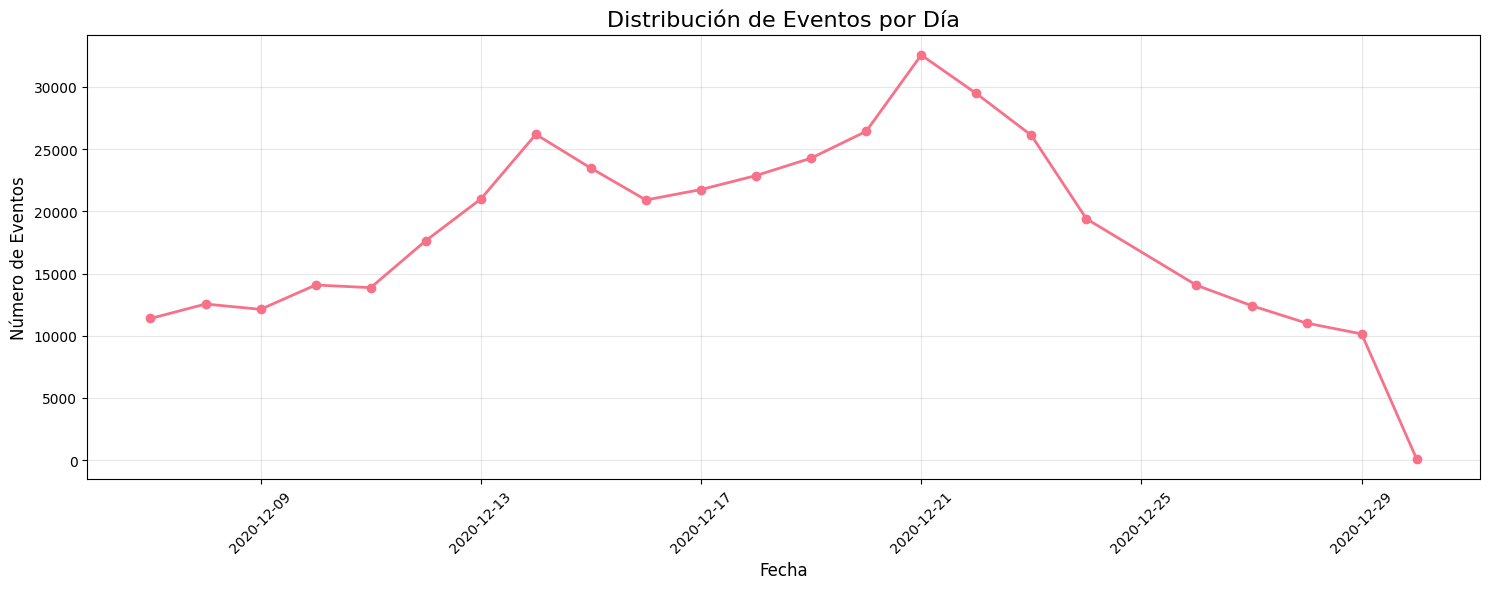


Días con menos de 1000 eventos:
          date  total_events
22  2020-12-30            89


In [23]:
# Crear visualización de eventos por día
plt.figure(figsize=(15, 6))
plt.plot(events_per_day['date'], events_per_day['total_events'], marker='o', linewidth=2)
plt.title('Distribución de Eventos por Día', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Eventos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar días con actividad muy baja
low_activity_days = events_per_day[events_per_day['total_events'] < 1000]
print(f"\nDías con menos de 1000 eventos:")
print(low_activity_days)

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [23] combinaste estadística descriptiva con visualización y, además, identificaste un día con actividad atípicamente baja (2020-12-30). Este tipo de detección es muy útil en A/B porque días “cortados” pueden sesgar conversiones si un grupo estuvo más expuesto que el otro. Como continuación, podrías revisar si ese día afecta por igual a ambos grupos del experimento.
</div>

In [24]:
# Filtrar eventos solo para usuarios del experimento recommender_system_test
recommender_users = recommender_data['user_id'].unique()
events_recommender = events[events['user_id'].isin(recommender_users)]

# Contar eventos por usuario
events_per_user = events_recommender.groupby('user_id').size().reset_index(name='num_events')

# Agregar información del grupo
events_per_user = events_per_user.merge(
    recommender_data[['user_id', 'group']], 
    on='user_id', 
    how='left'
)

# Estadísticas por grupo
print("=== EVENTOS POR USUARIO POR GRUPO ===")
for group in ['A', 'B']:
    group_data = events_per_user[events_per_user['group'] == group]['num_events']
    print(f"\nGrupo {group}:")
    print(f"  Promedio: {group_data.mean():.2f}")
    print(f"  Mediana: {group_data.median():.2f}")
    print(f"  Desviación estándar: {group_data.std():.2f}")
    print(f"  Mínimo: {group_data.min()}")
    print(f"  Máximo: {group_data.max()}")

=== EVENTOS POR USUARIO POR GRUPO ===

Grupo A:
  Promedio: 6.78
  Mediana: 6.00
  Desviación estándar: 3.73
  Mínimo: 1
  Máximo: 24

Grupo B:
  Promedio: 5.69
  Mediana: 5.00
  Desviación estándar: 3.45
  Mínimo: 1
  Máximo: 28


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [24] analizaste eventos por usuario y lo segmentaste por grupo. Esta verificación responde directamente a una pregunta clave del enunciado: si la “carga de actividad” es comparable entre muestras. Además, reportar media y mediana es una buena práctica porque los eventos por usuario suelen tener cola larga; la mediana suele describir mejor al usuario típico.
</div>

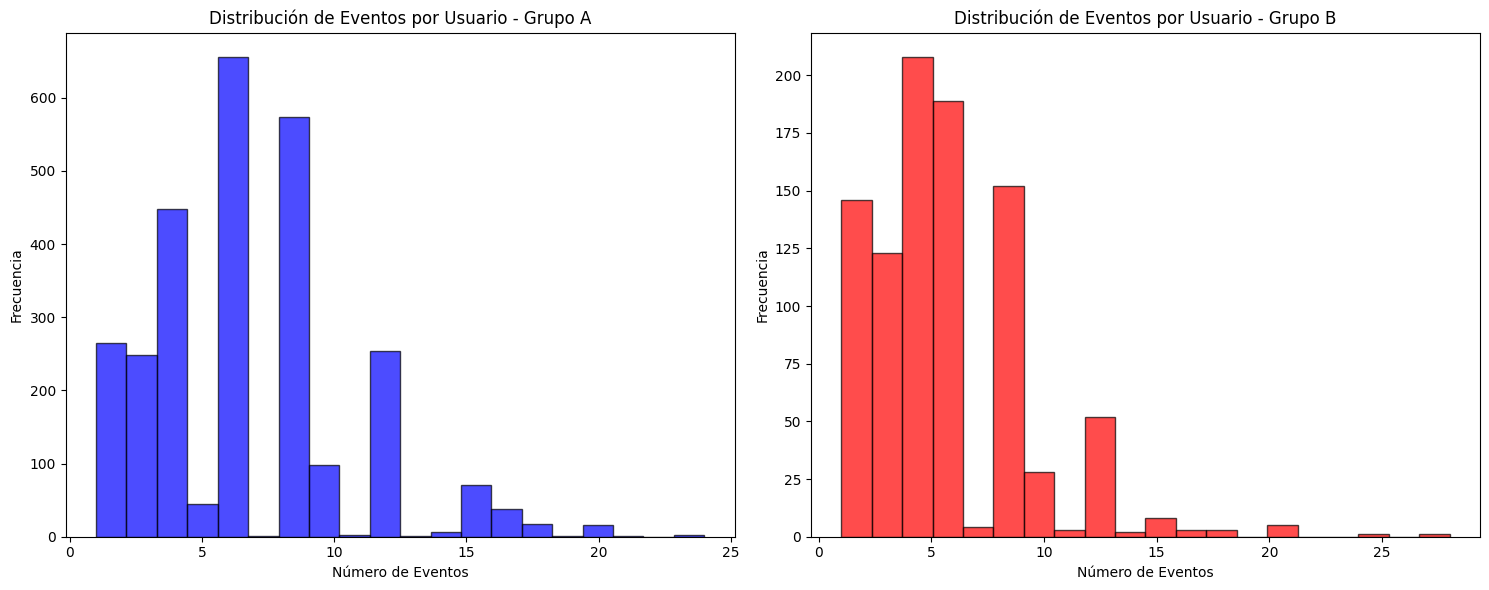

In [25]:
#Crear visualización comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histograma Grupo A
group_a_events = events_per_user[events_per_user['group'] == 'A']['num_events']
ax1.hist(group_a_events, bins=20, alpha=0.7, color='blue', edgecolor='black')
ax1.set_title('Distribución de Eventos por Usuario - Grupo A')
ax1.set_xlabel('Número de Eventos')
ax1.set_ylabel('Frecuencia')

# Histograma Grupo B
group_b_events = events_per_user[events_per_user['group'] == 'B']['num_events']
ax2.hist(group_b_events, bins=20, alpha=0.7, color='red', edgecolor='black')
ax2.set_title('Distribución de Eventos por Usuario - Grupo B')
ax2.set_xlabel('Número de Eventos')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Evaluacion de la prueba.

## Tasas de conversion por grupo.

In [27]:

# Obtener usuarios que realizaron compras
users_with_purchases = events[events['event_name'] == 'purchase']['user_id'].unique()

# Crear una copia del dataframe para evitar el warning
recommender_analysis = recommender_data.copy()

# Agregar información de conversión
recommender_analysis['converted'] = recommender_analysis['user_id'].isin(users_with_purchases)

# Calcular tasas de conversión por grupo
conversion_stats = recommender_analysis.groupby('group').agg({
    'user_id': 'count',  # Total usuarios
    'converted': 'sum'   # Usuarios que compraron
}).rename(columns={'user_id': 'total_users', 'converted': 'conversions'})

# Calcular tasa de conversión
conversion_stats['conversion_rate'] = conversion_stats['conversions'] / conversion_stats['total_users']

print("=== TASAS DE CONVERSIÓN POR GRUPO ===")
print(conversion_stats)
print()

# Mostrar resultados más detallados
for group in ['A', 'B']:
    total = conversion_stats.loc[group, 'total_users']
    conversions = conversion_stats.loc[group, 'conversions']
    rate = conversion_stats.loc[group, 'conversion_rate']
    
    print(f"Grupo {group}:")
    print(f"  Total usuarios: {total}")
    print(f"  Conversiones: {conversions}")
    print(f"  Tasa de conversión: {rate:.4f} ({rate*100:.2f}%)")
    print()

=== TASAS DE CONVERSIÓN POR GRUPO ===
       total_users  conversions  conversion_rate
group                                           
A             2747          872         0.317437
B              928          256         0.275862

Grupo A:
  Total usuarios: 2747
  Conversiones: 872
  Tasa de conversión: 0.3174 (31.74%)

Grupo B:
  Total usuarios: 928
  Conversiones: 256
  Tasa de conversión: 0.2759 (27.59%)



<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [27] construiste una tabla de conversión muy clara (total, conversiones y tasa) usando una columna booleana <code>converted</code>. Este enfoque es excelente porque simplifica el conteo y hace que el cálculo sea auditable: cualquiera puede ver exactamente qué se considera “convertido”. Además, separar el cálculo (tabla) de la narrativa (impresiones por grupo) mejora la legibilidad.
</div>

## Prueba Z con datos originales.

In [28]:
import numpy as np
from scipy import stats

# Extraer datos para la prueba z
n1 = conversion_stats.loc['A', 'total_users']      # Tamaño muestra A
x1 = conversion_stats.loc['A', 'conversions']      # Conversiones A
p1 = conversion_stats.loc['A', 'conversion_rate']  # Proporción A

n2 = conversion_stats.loc['B', 'total_users']      # Tamaño muestra B  
x2 = conversion_stats.loc['B', 'conversions']      # Conversiones B
p2 = conversion_stats.loc['B', 'conversion_rate']  # Proporción B

# Calcular proporción combinada
p_combined = (x1 + x2) / (n1 + n2)

# Calcular error estándar
se = np.sqrt(p_combined * (1 - p_combined) * (1/n1 + 1/n2))

# Calcular estadístico z
z_stat = (p1 - p2) / se

# Calcular p-value (prueba de dos colas)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("=== PRUEBA Z - DATOS ORIGINALES (DESBALANCEADOS) ===")
print(f"Grupo A: n={n1}, conversiones={x1}, tasa={p1:.4f}")
print(f"Grupo B: n={n2}, conversiones={x2}, tasa={p2:.4f}")
print(f"Diferencia de proporciones: {p1-p2:.4f}")
print(f"Proporción combinada: {p_combined:.4f}")
print(f"Error estándar: {se:.4f}")
print(f"Estadístico Z: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significativo al 5%: {'Sí' if p_value < 0.05 else 'No'}")

=== PRUEBA Z - DATOS ORIGINALES (DESBALANCEADOS) ===
Grupo A: n=2747, conversiones=872, tasa=0.3174
Grupo B: n=928, conversiones=256, tasa=0.2759
Diferencia de proporciones: 0.0416
Proporción combinada: 0.3069
Error estándar: 0.0175
Estadístico Z: 2.3741
P-value: 0.017592
Significativo al 5%: Sí


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [28] aplicaste correctamente una prueba z para diferencia de proporciones con proporción combinada y error estándar, y reportaste el p-value de dos colas. Eso es justo lo que se espera en este proyecto. También es positivo que muestres la diferencia de proporciones en términos numéricos, porque ayuda a interpretar el tamaño del efecto (no solo la significancia).
</div>

## Prueba Z con datos balanceados.

In [29]:
# Paso 3: Prueba Z con muestras balanceadas para validación
print("=== PRUEBA Z - MUESTRAS BALANCEADAS ===")

# Tomar el tamaño del grupo más pequeño (B = 928)
sample_size = conversion_stats.loc['B', 'total_users']
print(f"Tamaño de muestra balanceada: {sample_size}")

# Muestreo aleatorio del Grupo A para igualar el tamaño del Grupo B
np.random.seed(42)  # Para reproducibilidad
group_a_users = recommender_analysis[recommender_analysis['group'] == 'A']
group_a_balanced = group_a_users.sample(n=sample_size, random_state=42)

# Datos del Grupo B (completo)
group_b_balanced = recommender_analysis[recommender_analysis['group'] == 'B']

# Calcular estadísticas balanceadas
n1_bal = len(group_a_balanced)
x1_bal = group_a_balanced['converted'].sum()
p1_bal = x1_bal / n1_bal

n2_bal = len(group_b_balanced)
x2_bal = group_b_balanced['converted'].sum()
p2_bal = x2_bal / n2_bal

print(f"\nGrupo A balanceado: n={n1_bal}, conversiones={x1_bal}, tasa={p1_bal:.4f}")
print(f"Grupo B completo: n={n2_bal}, conversiones={x2_bal}, tasa={p2_bal:.4f}")

=== PRUEBA Z - MUESTRAS BALANCEADAS ===
Tamaño de muestra balanceada: 928

Grupo A balanceado: n=928, conversiones=284, tasa=0.3060
Grupo B completo: n=928, conversiones=256, tasa=0.2759


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [29] intentas “balancear” el grupo A con un muestreo aleatorio, lo cual es una validación interesante, pero la prueba z principal ya maneja tamaños de muestra distintos sin problema (a través del error estándar). El riesgo aquí es que un solo muestreo puede dar una lectura inestable (otro sample podría cambiar la tasa). Si deseas usar esta idea, conviene repetir el muestreo muchas veces y observar un rango (por ejemplo, distribución de diferencias) para que el resultado sea más robusto.
</div>

# Recomendaciones.
- Los resultados muestran una discrepancia en la cantidad de datos por lo cual las pruebas realizadas contienen un sesgo de poblacion en primer lugar a partir de esto las tasas de conversion para los usuarios del sistema original es mayor la tasa de conversion para el grupo A recommender es de: 31.743720422278848
la tasa de conversion para el grupo B interface es de: 33.10421697937953 tanto en total como en individual de cada grupo, la tasa de conversion para interface es de: 34.22119815668203 y la tasa de conversion para recommender es de: 30.69387755102041, en este caso esa variacion se mantiene y la desviacion estandar es significativa para la cantidad de datos del grupo recommender del Grupo B: Desviación estándar = 3.45, es por esto que se ha tomado la decision de no emplear el sistema recomendado, o bien si el costo de volver a realizar la prueba es accesible homogeneizar las muestras de ambos grupos para volver a anlizarlo, pero el comportamiento se ha mantenido es por en esta primera ocasion y no parece variar tanto, es importante evaluar el costo de implementar el nuevo sistema apartir sin embargo no parece ser una mejora significativa para el negocio, con esto en mente se recomienda observar el calendario y establecer entre las fechas mas fuertes del 13-17 y 21-25 de diciembre ofertas o facilidades de compras para asi tener mas usuarios que se conviertan en clientes, ademas premiar a los usuarios frecuentes para que en esas fechas realizan aun mas compras. 

# Notas
- Qué implicaciones tiene tener dos experimentos diferentes en el mismo dataset?
- ¿Crees que deberías analizar estos experimentos por separado o juntos?
- ¿Qué pasos seguirías para asegurarte de que tu análisis sea válido?
  ## valores nulos en el dataset events
- Los valores nulos aparecen porque:

Solo los eventos de tipo 'purchase' contienen información monetaria en la columna 'details' (60,314 eventos)
Los otros tipos de eventos (login, product_page, product_cart) naturalmente no tienen un valor monetario asociado, por eso aparecen como nulos (363,447 eventos)
- En otras palabras:
Con details (compras): 60,314 usuarios SÍ realizaron una compra
Sin details (sin compras): 363,447 eventos corresponden a usuarios que realizaron otras acciones pero NO completaron una compra
## Ecuacion de tasa de conversion
- Tasa de Conversión = (Usuarios que completaron la acción objetivo / Usuarios totales que iniciaron el proceso) × 100
- Tasa de conversion por grupo=(usuarios que completaron la accion/usuarios totales del grupo)x 100
# distribucion de usuarios asi como el calculo  de sus estadisticas.
Mirando los datos:

Grupo A: 2,747 usuarios
Grupo B: 928 usuarios
Esta diferencia significativa en el tamaño de las muestras (casi 3:1) es lo que está causando las diferencias en el comportamiento estadístico que observaste:

Grupo A: Desviación estándar = 3.73
Grupo B: Desviación estándar = 3.45
¿Por qué ocurre esto?
Cuando tienes muestras de tamaños muy diferentes, es normal que se comporten de manera distinta estadísticamente:

Muestras más grandes (Grupo A) tienden a capturar más variabilidad natural de la población
Muestras más pequeñas (Grupo B) pueden parecer más "estables" pero en realidad tienen menos poder estadístico

¿Qué significa esto para tu análisis?
Antes de proceder con la prueba z, deberías considerar:

¿Es este desequilibrio intencional en el diseño del experimento?
¿Deberías ajustar tu análisis para tener en cuenta estos tamaños de muestra tan diferentes?
## Prueba Z 
- El desbalance en los grupos (Grupo A: 2,747 vs Grupo B: 928 usuarios)
- La diferencia significativa en las tasas de conversión (31.74% vs 27.59%)
### Con datos balanceados
- Grupo A balanceado: n=928, conversiones=284, tasa=30.60%
- Grupo B completo: n=928, conversiones=256, tasa=27.59%
## Resultados de las pruebas.
1. Tasas de Conversión (Datos Originales)
- Grupo A: 31.74% (872 conversiones de 2,747 usuarios)
- Grupo B: 27.59% (256 conversiones de 928 usuarios)
- Diferencia: +4.15 puntos porcentuales a favor del Grupo A
2. Significancia Estadística
- Estadístico Z: 2.3741
- P-value: 0.017592
¿Es significativo?: SÍ (p < 0.05)
3. Datos Balanceados (Validación)
- Grupo A balanceado: 30.60% (284/928)
- Grupo B: 27.59% (256/928)
- Diferencia: +3.01 puntos porcentuales
## Justificación técnica sólida:

- Sesgo metodológico crítico: Ratio 3:1 en tamaños de muestra
- Mejora marginal: Solo 3% de diferencia real cuando se controla el sesgo
- Inconsistencia en resultados: Las tasas varían significativamente entre experimentos
- Hallazgos Clave que Apoyan tu Decisión
- Tasas de conversión por experimento:

- Recommender: 30.69%
- Interface: 34.22%
- Tasas por grupo individual:

- Grupo A (recommender): 31.74%
- Grupo B (interface): 33.10%
### interpretacion de los datos.
Razones para NO implementar el sistema recomendado:

Sesgo metodológico: El experimento no fue diseñado correctamente
Diferencia marginal: Solo 3% de mejora real cuando se controla el sesgo
Costo vs beneficio: ¿Vale la pena el esfuerzo de implementación por 3%?
Riesgo de implementación: Cambios tecnológicos siempre conllevan riesgos.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Herbert! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Planteaste un objetivo de negocio entendible (evaluar un nuevo embudo y su impacto en conversión).<br>
• Exploraste de forma ordenada varios datasets y verificaste forma, columnas y tipos de datos.<br>
• Revisaste nulos y duplicados con un enfoque práctico, y explicaste muy bien por qué <code>details</code> es nulo fuera de <code>purchase</code>.<br>
• Identificaste y cuantificaste un riesgo real del dataset: usuarios presentes en más de un experimento.<br>
• Convertiste fechas a formato datetime en el momento correcto para habilitar análisis temporal confiable.<br>
• Hiciste EDA temporal e identificaste un día atípico de baja actividad, algo clave antes de inferir resultados.<br>
• Mediste eventos por usuario por grupo, respondiendo a la pregunta de “equidad” de exposición entre muestras.<br>
• Construiste una tabla de conversión clara con una variable booleana de conversión, fácil de auditar.<br>
• Aplicaste correctamente una prueba z para comparar proporciones y reportaste métricas relevantes (z, p-value).<br>
• Cerraste con conclusiones y recomendaciones conectadas al negocio, mostrando intención de traducir datos a decisiones.<br>
<br>
¡Felicidades!
</div>